We have a characterization of the constant covers using permutations of length at most $n$. Now we seek to characterize constant covers by number of terms, which we shall call the order $r$ of a constant cover.  Previously Gabriel, Peter, and Joel characterized the non-vanishing covers of order $\leq 5$. It would be nice to have a complete characterization, but that is perhaps too ambitious. What would be nice is to characterize vanishing covers of order at most $5$, as well as all covers of order at most 6.

If we had this, we could settle some conjectures of their paper. 

As we know from their paper (which we need to verify if this applies to vanishing covers), their must be two permutations of max length in a constant cover. Hence for $r=2$, only $(n,n)$ is possible, but this is non-vanishing if they are disctinct which they must be. So no vanishing for $r=2$.

For $r=3$, $(n,n,n)$ is exclusively latin squares which are non-vanishing. For $(n,n, <n)$, lemma 4.15 tells us that $<n$ could only be $n-1$. Which again gives us non-vanishing by exhaustive search and a lemma bounding $n$.

In [2]:
#Input: Two positive integers n,r representing the length of the longest permutation and the number of permutations.
#Output: A list of possible length sequences for a constant cover according to lemma 4.19 of Six Permutation Patterns Force Quasirandomness.

def possibleLengths(n,r):
    possibilities = []
    stack = []
    stack.append([n,n])
    while len(stack) > 0:
        lenList = stack.pop()
        if len(lenList) >= r:
            possibilities.append(lenList)
            continue
        lower_bound = lemma419(lenList,n,r)
        for k in range(lower_bound,lenList[-1]+1):
            stack.append(lenList+[k])
    return possibilities
  
#Input: A list of lengths, the maximum length n, and the maximum number of terms r.
#Output: The lower bound on the next term in the sequence according to lemma 4.19 of Six Permutation Patterns Force Quasirandomness
def lemma419(lenList,n,r):
    if len(lenList) >= r:
        return None
    else:
        lower_bound = n+1 - sum([n-k+1 for k in lenList])
        return max(lower_bound,2)
    
#Input: A list of lengths
#Ouput: The upper bound on n as given by lemma 4.17 in Six Permutation Patterns Force Quasirandomness
def lemma417(lenList,n):
    r = len(lenList)
    upperbound = (n+1)*(r-1) - sum(lenList[0:-1]) + 2
    return upperbound

#Input: A list of candidate length sequences and an integer n
#Ouput: A copy of the list which includes only those candidates which do not violate lemma 4.17 with n.
def trimViolater(potentials,n):
    new_list = []
    for li in potentials:
        if lemma417(li,n) >= n-2:
            new_list.append(li)
    return new_list
#Input: A list of lists of lengths, and the maximum length $n$.
#Returns: None
#Output: Prints all lists in terms of generic n.
def displayLenWRTn(potentials, n):
    for li in potentials:
        print(["n"+str(int(k)-int(n)) for k in li])
        
def possibleLengthsCountUptoR(R):
    for r in range(2,R+1):
        n=100000
        print(len(possibleLengths(n,r)))
        
    
n = 18
#lists200 = possibleLengths(n,6)
for 
lists100 = possibleLengths(n,6)
#lists18 = possibleLengths(5,5)
#displayLenWRTn(lists18,n)

#print(len(lists200) == len(lists100))

#bound = max([lemma417(li,100) for li in lists100])
#print(bound)
for li in lists100:
    print(li)

[18, 18, 18, 18, 18, 18]
[18, 18, 18, 18, 18, 17]
[18, 18, 18, 18, 18, 16]
[18, 18, 18, 18, 18, 15]
[18, 18, 18, 18, 18, 14]
[18, 18, 18, 18, 17, 17]
[18, 18, 18, 18, 17, 16]
[18, 18, 18, 18, 17, 15]
[18, 18, 18, 18, 17, 14]
[18, 18, 18, 18, 17, 13]
[18, 18, 18, 18, 16, 16]
[18, 18, 18, 18, 16, 15]
[18, 18, 18, 18, 16, 14]
[18, 18, 18, 18, 16, 13]
[18, 18, 18, 18, 16, 12]
[18, 18, 18, 18, 15, 15]
[18, 18, 18, 18, 15, 14]
[18, 18, 18, 18, 15, 13]
[18, 18, 18, 18, 15, 12]
[18, 18, 18, 18, 15, 11]
[18, 18, 18, 17, 17, 17]
[18, 18, 18, 17, 17, 16]
[18, 18, 18, 17, 17, 15]
[18, 18, 18, 17, 17, 14]
[18, 18, 18, 17, 17, 13]
[18, 18, 18, 17, 17, 12]
[18, 18, 18, 17, 16, 16]
[18, 18, 18, 17, 16, 15]
[18, 18, 18, 17, 16, 14]
[18, 18, 18, 17, 16, 13]
[18, 18, 18, 17, 16, 12]
[18, 18, 18, 17, 16, 11]
[18, 18, 18, 17, 15, 15]
[18, 18, 18, 17, 15, 14]
[18, 18, 18, 17, 15, 13]
[18, 18, 18, 17, 15, 12]
[18, 18, 18, 17, 15, 11]
[18, 18, 18, 17, 15, 10]
[18, 18, 18, 17, 14, 14]
[18, 18, 18, 17, 14, 13]


In [4]:
possibleLengthsCountUptoR(9)

1
2
6
27
192
2280
47097
1735803


https://oeis.org/A003513

In [9]:
initialn = 100
r = 5
count = 0
upperBoundOnn = max([lemma417(li,initialn) for li in possibleLengths(initialn,r)])
#print(upperBoundOnn)
for n in range(upperBoundOnn,2,-1):
    for li in trimViolater(possibleLengths(n,r),n):
        count += 1
        print(count,end=": ")
        print(li)

1: [10, 10, 10, 8, 8]
2: [10, 10, 10, 8, 7]
3: [10, 10, 10, 8, 6]
4: [10, 10, 10, 8, 5]
5: [10, 10, 9, 9, 9]
6: [10, 10, 9, 9, 8]
7: [10, 10, 9, 9, 7]
8: [10, 10, 9, 9, 6]
9: [10, 10, 9, 9, 5]
10: [10, 10, 9, 8, 8]
11: [10, 10, 9, 8, 7]
12: [10, 10, 9, 8, 6]
13: [10, 10, 9, 8, 5]
14: [10, 10, 9, 8, 4]
15: [10, 10, 9, 7, 7]
16: [10, 10, 9, 7, 6]
17: [10, 10, 9, 7, 5]
18: [10, 10, 9, 7, 4]
19: [10, 10, 9, 7, 3]
20: [9, 9, 9, 8, 8]
21: [9, 9, 9, 8, 7]
22: [9, 9, 9, 8, 6]
23: [9, 9, 9, 8, 5]
24: [9, 9, 9, 7, 7]
25: [9, 9, 9, 7, 6]
26: [9, 9, 9, 7, 5]
27: [9, 9, 9, 7, 4]
28: [9, 9, 8, 8, 8]
29: [9, 9, 8, 8, 7]
30: [9, 9, 8, 8, 6]
31: [9, 9, 8, 8, 5]
32: [9, 9, 8, 8, 4]
33: [9, 9, 8, 7, 7]
34: [9, 9, 8, 7, 6]
35: [9, 9, 8, 7, 5]
36: [9, 9, 8, 7, 4]
37: [9, 9, 8, 7, 3]
38: [9, 9, 8, 6, 6]
39: [9, 9, 8, 6, 5]
40: [9, 9, 8, 6, 4]
41: [9, 9, 8, 6, 3]
42: [9, 9, 8, 6, 2]
43: [8, 8, 8, 8, 8]
44: [8, 8, 8, 8, 7]
45: [8, 8, 8, 8, 6]
46: [8, 8, 8, 8, 5]
47: [8, 8, 8, 7, 7]
48: [8, 8, 8, 7, 6]
49: [8,

In [1]:
%run ./combinations_of_permutations.ipynb

In [9]:
p1432 = combination_of_permutations([1],[[1,4,3,2]])
p1432.genFuzzyMatrix(7)

[  480/7   240/7    96/7    24/7       0       0       0]
[  240/7   120/7    48/7    24/7    48/7   120/7   240/7]
[   96/7    48/7  192/35  312/35  576/35   192/7   288/7]
[   24/7    24/7  312/35   120/7  888/35   216/7   216/7]
[      0    48/7  576/35  888/35 1056/35   192/7    96/7]
[      0   120/7   192/7   216/7   192/7   120/7       0]
[      0   240/7   288/7   216/7    96/7       0       0]

In [4]:
p123 = combination_of_permutations([1],[[1,2,3]])
p123.genFuzzyMatrix(5)

print(36+18+6)


60


In [10]:
for p in Permutations(4):
    for q in Permutations(4):
        print(combination_of_permutations([1],[p]).genFuzzyMatrix(4)-combination_of_permutations([1],[q]).genFuzzyMatrix(4))
        print()

[0 0 0 0]
[0 0 0 0]
[0 0 0 0]
[0 0 0 0]

[ 0  0  0  0]
[ 0  0  0  0]
[ 0  0  1 -1]
[ 0  0 -1  1]

[ 0  0  0  0]
[ 0  1 -1  0]
[ 0 -1  1  0]
[ 0  0  0  0]

[ 0  0  0  0]
[ 0  1 -1  0]
[ 0  0  1 -1]
[ 0 -1  0  1]

[ 0  0  0  0]
[ 0  1  0 -1]
[ 0 -1  1  0]
[ 0  0 -1  1]

[ 0  0  0  0]
[ 0  1  0 -1]
[ 0  0  0  0]
[ 0 -1  0  1]

[ 1 -1  0  0]
[-1  1  0  0]
[ 0  0  0  0]
[ 0  0  0  0]

[ 1 -1  0  0]
[-1  1  0  0]
[ 0  0  1 -1]
[ 0  0 -1  1]

[ 1 -1  0  0]
[ 0  1 -1  0]
[-1  0  1  0]
[ 0  0  0  0]

[ 1 -1  0  0]
[ 0  1 -1  0]
[ 0  0  1 -1]
[-1  0  0  1]

[ 1 -1  0  0]
[ 0  1  0 -1]
[-1  0  1  0]
[ 0  0 -1  1]

[ 1 -1  0  0]
[ 0  1  0 -1]
[ 0  0  0  0]
[-1  0  0  1]

[ 1  0 -1  0]
[-1  1  0  0]
[ 0 -1  1  0]
[ 0  0  0  0]

[ 1  0 -1  0]
[-1  1  0  0]
[ 0  0  1 -1]
[ 0 -1  0  1]

[ 1  0 -1  0]
[ 0  0  0  0]
[-1  0  1  0]
[ 0  0  0  0]

[ 1  0 -1  0]
[ 0  0  0  0]
[ 0  0  1 -1]
[-1  0  0  1]

[ 1  0 -1  0]
[ 0  1  0 -1]
[-1  0  1  0]
[ 0 -1  0  1]

[ 1  0 -1  0]
[ 0  1  0 -1]
[ 0 -1  1  0]
[-1  

[ 0 -1  0  1]
[ 0  1 -1  0]
[ 0  0  0  0]
[ 0  0  1 -1]

[ 0 -1  0  1]
[ 0  1 -1  0]
[ 1  0  0 -1]
[-1  0  1  0]

[ 0 -1  0  1]
[ 0  1  0 -1]
[ 0  0  0  0]
[ 0  0  0  0]

[ 0 -1  0  1]
[ 0  1  0 -1]
[ 1  0 -1  0]
[-1  0  1  0]

[ 0  0 -1  1]
[-1  1  0  0]
[ 1 -1  0  0]
[ 0  0  1 -1]

[ 0  0 -1  1]
[-1  1  0  0]
[ 1  0  0 -1]
[ 0 -1  1  0]

[ 0  0 -1  1]
[ 0  0  0  0]
[ 0  0  0  0]
[ 0  0  1 -1]

[ 0  0 -1  1]
[ 0  0  0  0]
[ 1  0  0 -1]
[-1  0  1  0]

[ 0  0 -1  1]
[ 0  1  0 -1]
[ 0  0  0  0]
[ 0 -1  1  0]

[ 0  0 -1  1]
[ 0  1  0 -1]
[ 1 -1  0  0]
[-1  0  1  0]

[ 0  0  0  0]
[-1  1  0  0]
[ 1 -1  0  0]
[ 0  0  0  0]

[ 0  0  0  0]
[-1  1  0  0]
[ 1  0 -1  0]
[ 0 -1  1  0]

[0 0 0 0]
[0 0 0 0]
[0 0 0 0]
[0 0 0 0]

[ 0  0  0  0]
[ 0  0  0  0]
[ 1  0 -1  0]
[-1  0  1  0]

[ 0  0  0  0]
[ 0  1 -1  0]
[ 0  0  0  0]
[ 0 -1  1  0]

[ 0  0  0  0]
[ 0  1 -1  0]
[ 1 -1  0  0]
[-1  0  1  0]

[-1  0  0  1]
[ 0  0  0  0]
[ 0  0  0  0]
[ 1  0  0 -1]

[-1  0  0  1]
[ 0  0  0  0]
[ 0  0  1 -1]
[ 1  

In [93]:
n = 4
for q in Permutations(n):
        print(combination_of_permutations([1],[q]))
        print(combination_of_permutations([1],[q]).genFuzzyMatrix(n+2))
        print()

1*(1234) 
[  40/3   16/3    4/3      0      0      0]
[  16/3 104/15   16/3   12/5      0      0]
[   4/3   16/3  92/15   24/5   12/5      0]
[     0   12/5   24/5  92/15   16/3    4/3]
[     0      0   12/5   16/3 104/15   16/3]
[     0      0      0    4/3   16/3   40/3]

1*(1243) 
[  40/3   16/3    4/3      0      0      0]
[  16/3 104/15   16/3   12/5      0      0]
[   4/3   16/3  74/15   14/5    8/5      4]
[     0   12/5   14/5   14/5      4      8]
[     0      0    8/5      4   32/5      8]
[     0      0      4      8      8      0]

1*(1324) 
[ 40/3  16/3   4/3     0     0     0]
[ 16/3 32/15 44/15  24/5  24/5     0]
[  4/3 44/15 74/15     6  24/5     0]
[    0  24/5     6 74/15 44/15   4/3]
[    0  24/5  24/5 44/15 32/15  16/3]
[    0     0     0   4/3  16/3  40/3]

1*(1342) 
[ 40/3  16/3   4/3     0     0     0]
[ 16/3 32/15 44/15  24/5  24/5     0]
[  4/3  8/15 38/15  26/5  32/5     4]
[    0   4/5     2  18/5  28/5     8]
[    0  16/5  16/5  12/5  16/5     8]
[    0     

In [100]:
peters = combination_of_permutations([1],[[1,4,2,5,3,6]])
peters.genFuzzyMatrix(7)

#iden = combination_of_permutations([1],[[1,2,3,4,5,6]])
#iden.genFuzzyMatrix(7)

[36/7  6/7    0    0    0    0    0]
[ 6/7  1/7    0 15/7 20/7    0    0]
[   0 20/7  8/7  6/7  8/7    0    0]
[   0 15/7  6/7    0  6/7 15/7    0]
[   0    0  8/7  6/7  8/7 20/7    0]
[   0    0 20/7 15/7    0  1/7  6/7]
[   0    0    0    0    0  6/7 36/7]

In [2]:
max_length = 6
cumulative_permutations =  genPermutationsBetween(2,max_length)
vectorized_fuzzy_matrices_list = []

for perm in cumulative_permutations:
    fuzzy_perm_matrix = genPermMatrix(perm,max_length)
    vectorized_fuzzy_matrices_list.append(np.array(fuzzy_perm_matrix).flatten())
    
vectorized_fuzzy_matrices_array = np.vstack(vectorized_fuzzy_matrices_list).transpose()
vectorized_fuzzy_matrices_array_sage = matrix(QQ,vectorized_fuzzy_matrices_array)
van_covers_basis = vectorized_fuzzy_matrices_array_sage.right_kernel().basis()



#W = Matrix(QQ,cover_matrix_with_extra_row).column_space()
#W = V.subspace_with_basis(basis_129)
#print(V)
#print(W)

#W.is_subspace(V)


In [6]:
len(van_covers_basis)

846

In [101]:
sub_covers = []
for cover in van_covers_basis:
    keep_cover = True
    CoP = combination_of_permutations.vector(cover,cumulative_permutations)
    for perm in CoP.get_terms():
        if len(perm)!= 6:
            keep_cover = False
    if CoP.number_of_terms()%2 == 1 and CoP.number_of_terms() == 5:
        CoP.sort()
        sub_covers.append(CoP)
        print(CoP)
        print(CoP.number_of_terms())
        print()   

1*(563412) -1*(564321) -1*(653421) -1*(654312) + 2*(654321) 
5



$\alpha$= 1*(651324) -1*(651432) -1*(653214) + 1*(653421) + 1*(654231) + 1*(654312) -2*(654321) 

$\beta$ = 1*(514236) -1*(543216) -1*(615432) + 1*(645321) + 1*(653421) + 1*(654312) -2*(654321)

In [102]:
iso_classes = [[]]
for cover in sub_covers:
    g = cover.weightedCompGraph()
    if g is None:
        continue
    for clas in iso_classes:
        if len(clas) == 0:
            clas.append(g)
            iso_classes.append([])
            break
        elif g.is_isomorphic(clas[0]):
            clas.append(g)
            break

1


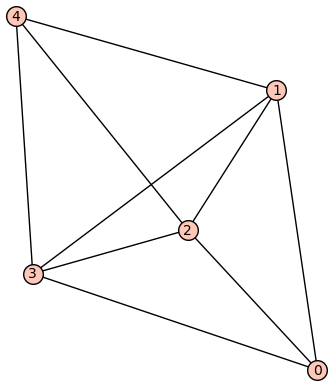

In [103]:
print(len(iso_classes)-1)
for clas in iso_classes:
    if len(clas) >= 1:
        clas[0].show()

In [72]:
gprime = sub_covers[1].weightedCompGraph()
count = 0
for cover in sub_covers:
    termList = cover.get_terms()
    g = graphs.IntersectionGraph(termList)
    print(count,end=": ")
    print(g.is_isomorphic(gprime))
    count += 1
   

0: False
1: False
2: False
3: False
4: False
5: False
6: False
7: False
8: False
9: False
10: False
11: False
12: False
13: False
14: False
15: False
16: False
17: False
18: False
19: False
20: False
21: False
22: False
23: False
24: False
25: False
26: False
27: False
28: False
29: False
30: False
31: False
32: False


1*(145236) -1*(165432) -1*(543216) + 1*(564321) + 1*(653421) + 1*(654312) -2*(654321) 


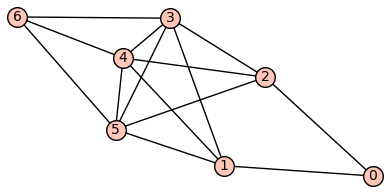

1*(145362) -1*(165432) -1*(543261) + 1*(564321) + 1*(653421) + 1*(654231) -2*(654321) 


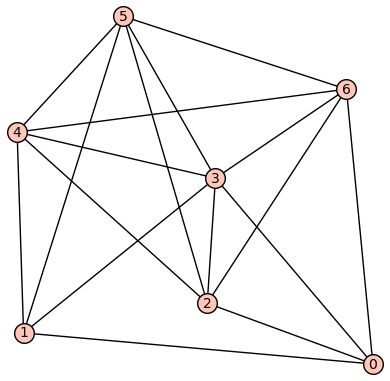

1*(153462) -1*(165432) -1*(543261) + 1*(564321) + 1*(645321) + 1*(654231) -2*(654321) 


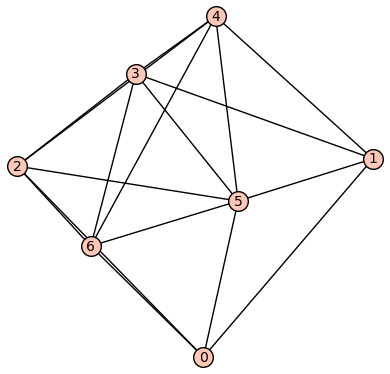

1*(154632) -1*(165432) -1*(543621) + 1*(564321) + 1*(645321) + 1*(653421) -2*(654321) 


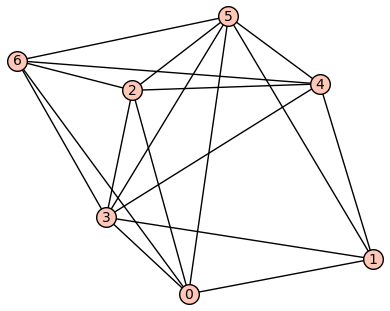

1*(163425) -1*(165432) -1*(643215) + 1*(645321) + 1*(654231) + 1*(654312) -2*(654321) 


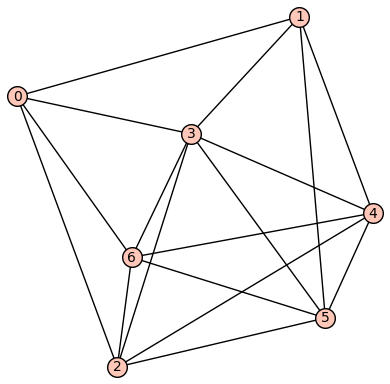

1*(164235) -1*(165432) -1*(643215) + 1*(645321) + 1*(653421) + 1*(654312) -2*(654321) 


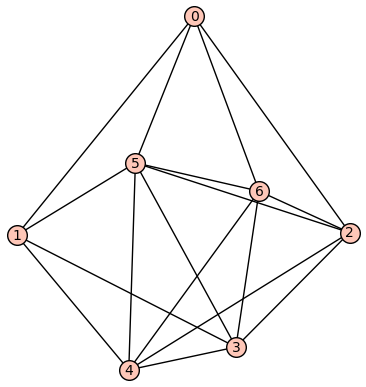

1*(164352) -1*(165432) -1*(643251) + 1*(645321) + 1*(653421) + 1*(654231) -2*(654321) 


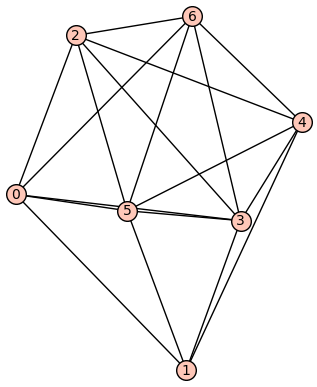

1*(165324) -1*(165432) -1*(653214) + 1*(653421) + 1*(654231) + 1*(654312) -2*(654321) 


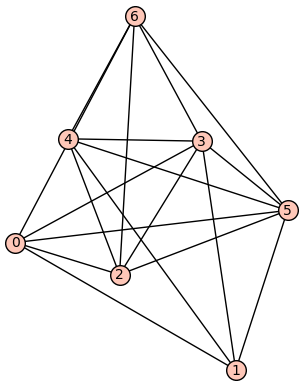

1*(245316) -1*(265431) -1*(543216) + 1*(564321) + 1*(653421) + 1*(654231) -2*(654321) 


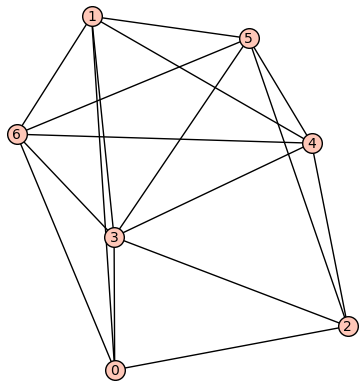

1*(245361) -1*(265431) -1*(543261) + 1*(564321) + 1*(653421) + 1*(654231) -2*(654321) 


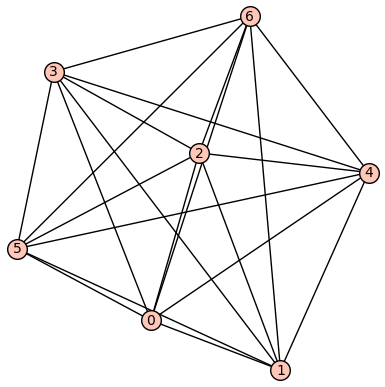

1*(253416) -1*(265431) -1*(543216) + 1*(564321) + 1*(645321) + 1*(654231) -2*(654321) 


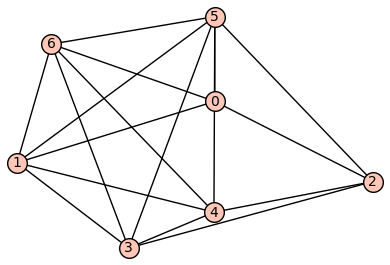

1*(253461) -1*(265431) -1*(543261) + 1*(564321) + 1*(645321) + 1*(654231) -2*(654321) 


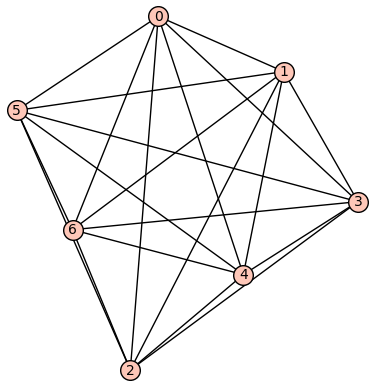

1*(254631) -1*(265431) -1*(543621) + 1*(564321) + 1*(645321) + 1*(653421) -2*(654321) 


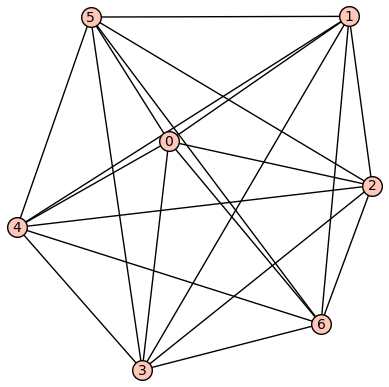

1*(264315) -1*(265431) -1*(643215) + 1*(645321) + 1*(653421) + 1*(654231) -2*(654321) 


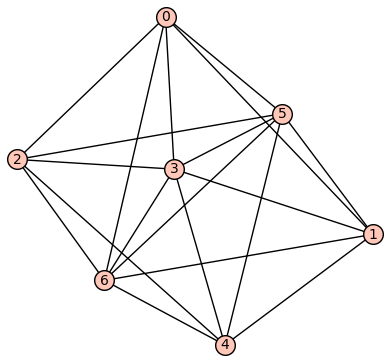

1*(264351) -1*(265431) -1*(643251) + 1*(645321) + 1*(653421) + 1*(654231) -2*(654321) 


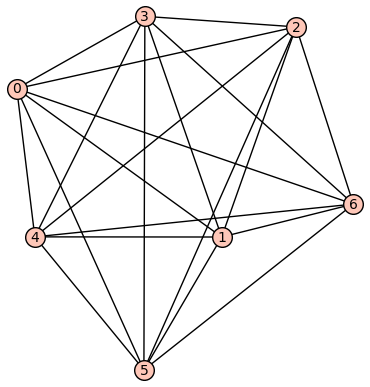

1*(354216) -1*(365421) -1*(543216) + 1*(564321) + 1*(645321) + 1*(653421) -2*(654321) 


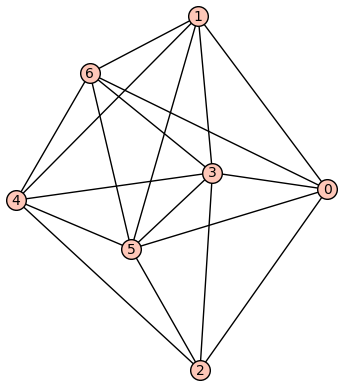

1*(354261) -1*(365421) -1*(543261) + 1*(564321) + 1*(645321) + 1*(653421) -2*(654321) 


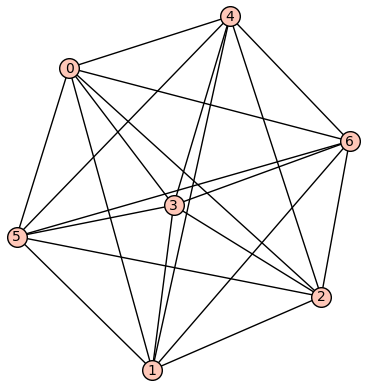

1*(354621) -1*(365421) -1*(543621) + 1*(564321) + 1*(645321) + 1*(653421) -2*(654321) 


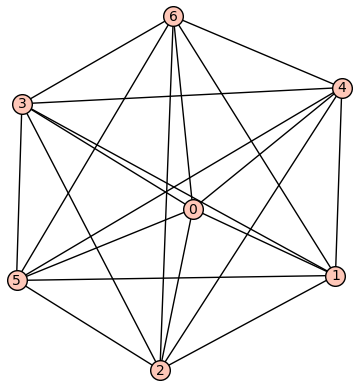

1*(513426) -1*(543216) -1*(615432) + 1*(645321) + 1*(654231) + 1*(654312) -2*(654321) 


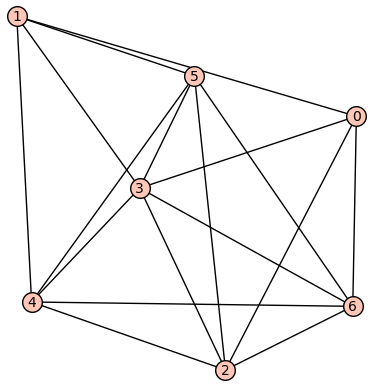

1*(514236) -1*(543216) -1*(615432) + 1*(645321) + 1*(653421) + 1*(654312) -2*(654321) 


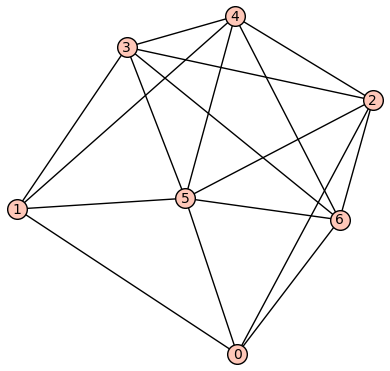

1*(514362) -1*(543261) -1*(615432) + 1*(645321) + 1*(653421) + 1*(654231) -2*(654321) 


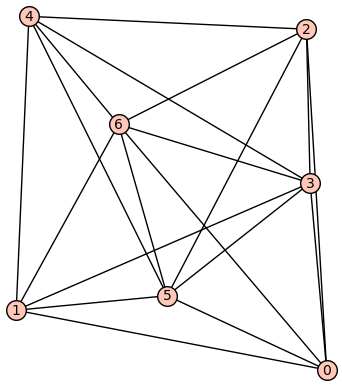

1*(524316) -1*(543216) -1*(625431) + 1*(645321) + 1*(653421) + 1*(654231) -2*(654321) 


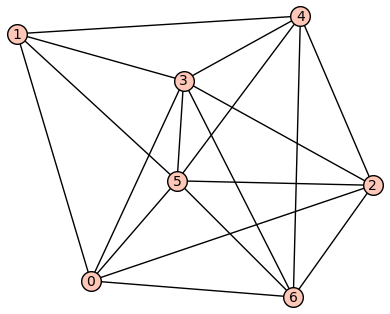

1*(524361) -1*(543261) -1*(625431) + 1*(645321) + 1*(653421) + 1*(654231) -2*(654321) 


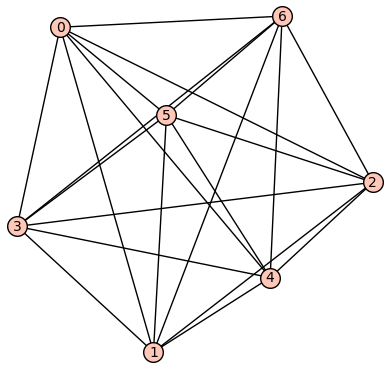

1*(541326) -1*(543216) -1*(651432) + 1*(653421) + 1*(654231) + 1*(654312) -2*(654321) 


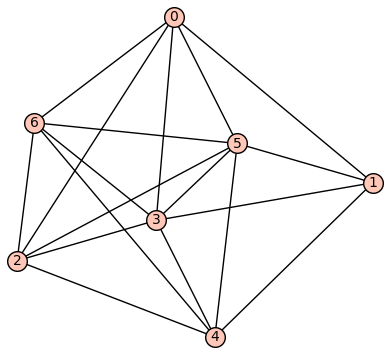

1*(613425) -1*(615432) -1*(643215) + 1*(645321) + 1*(654231) + 1*(654312) -2*(654321) 


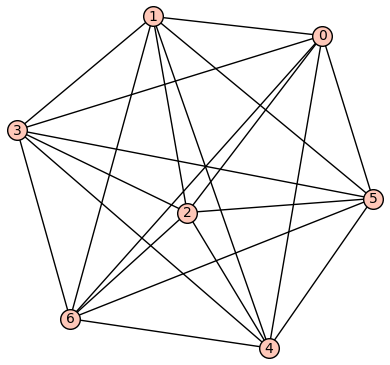

1*(614235) -1*(615432) -1*(643215) + 1*(645321) + 1*(653421) + 1*(654312) -2*(654321) 


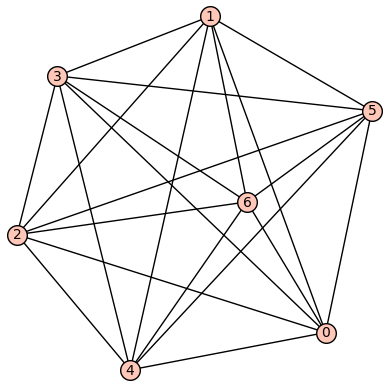

1*(614352) -1*(615432) -1*(643251) + 1*(645321) + 1*(653421) + 1*(654231) -2*(654321) 


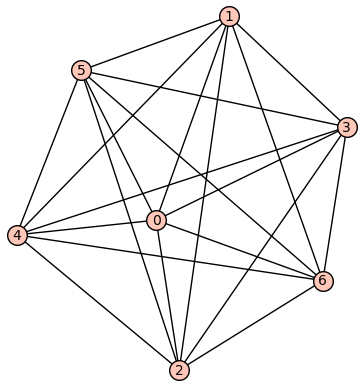

1*(615324) -1*(615432) -1*(653214) + 1*(653421) + 1*(654231) + 1*(654312) -2*(654321) 


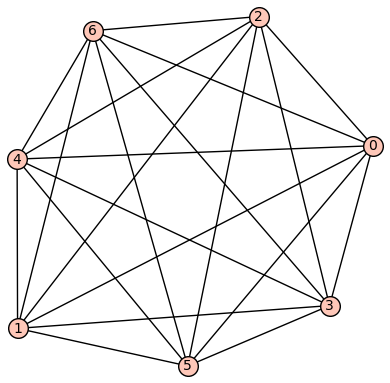

1*(624315) -1*(625431) -1*(643215) + 1*(645321) + 1*(653421) + 1*(654231) -2*(654321) 


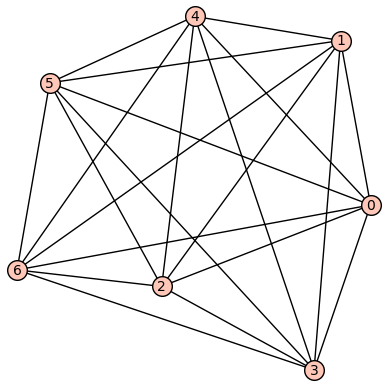

1*(624351) -1*(625431) -1*(643251) + 1*(645321) + 1*(653421) + 1*(654231) -2*(654321) 


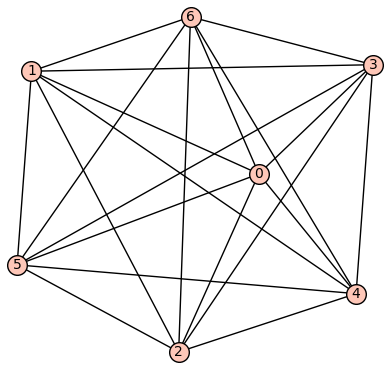

1*(641325) -1*(643215) -1*(651432) + 1*(653421) + 1*(654231) + 1*(654312) -2*(654321) 


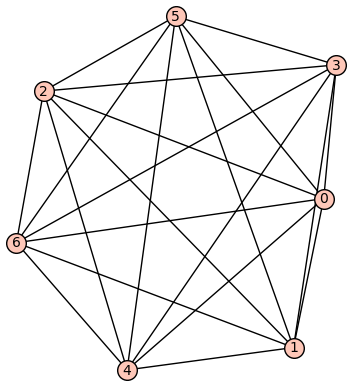

1*(651324) -1*(651432) -1*(653214) + 1*(653421) + 1*(654231) + 1*(654312) -2*(654321) 


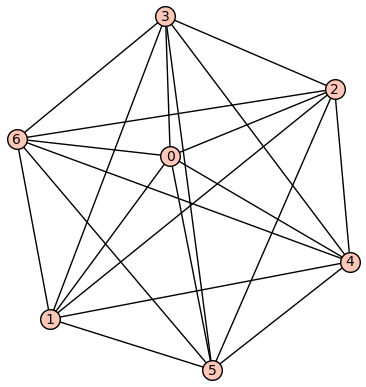

In [74]:
for cover in sub_covers:
    g = cover.weightedCompGraph()
    if g is not None:
        print(cover)
        g.show()

In [4]:
%run ./combinations_of_permutations.ipynb

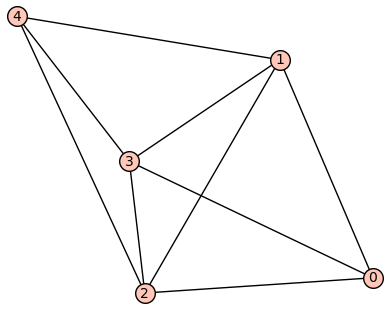

In [67]:
g = sub_covers[0].weightedCompGraph()
g.show()

In [16]:
a = Permutation([5,1,4,2,3,6])
f= Permutation([6,5,4,3,1,2])
aInv = a.inverse()
aInvf = aInv * f
print(aInvf.cycle_string(singletons=False))

c= Permutation([6,1,5,4,3,2])
g= Permutation([6,5,4,3,2,1])
cInv = c.inverse()
cInvg = cInv * g
print(cInvg.cycle_string(singletons=False))


aInvc = aInv * c
print(aInvc.cycle_string(singletons=False))

(1,5,6,2,3)
(1,5,4,3,2)
(2,4,5,6)


t-design, replace 123 and 321 with all possible embeddings.

Is this a necessary condition for quasirandom forcing linear combination.

Do we average the embeddings, multiplicity $\frac{1}{4}$ and then double according to coefficients/

In [32]:
print(2*rho_star)

2*(123) + 2*(321) + 2*(2143) + 2*(3412) + 1*(2413) + 1*(3142) 


Let's find Peter's Histogram.

We wish to loop over a set of permutations, and see how many non-zero entries appear in the fuzzy matrix. 
For various $n$, and for various $n+1$,$n+2$ etc. We can construct a nice table from this.

In [22]:
nmax = 7
M = Matrix(QQ,nmax, sum([factorial(i) for i in range(2,nmax+1)]))
for n in range(2,nmax+1):
    permlist = genPermutationsBetween(2,n)
    for i, perm in enumerate(permlist):
        M[n-2,i] = np.count_nonzero(combination_of_permutations([1],[perm]).genFuzzyMatrix(n))
        

In [32]:
nmax = 7
for perm in genPermutationsBetween(2,6):
    for n in range(2,nmax+1):
        if n < len(perm):
            print(f"{0:04}",end=" ")
        else:
            print(f"{np.count_nonzero(combination_of_permutations([1],[perm]).genFuzzyMatrix(n)):04}", end=" ")
            #print(np.count_nonzero(combination_of_permutations([1],[perm]).genFuzzyMatrix(n)),end=" ")
    print()

0002 0007 0014 0023 0034 0047 
0002 0007 0014 0023 0034 0047 
0000 0003 0010 0019 0030 0043 
0000 0003 0011 0020 0031 0044 
0000 0003 0011 0020 0031 0044 
0000 0003 0011 0020 0031 0044 
0000 0003 0011 0020 0031 0044 
0000 0003 0010 0019 0030 0043 
0000 0000 0004 0013 0024 0037 
0000 0000 0004 0014 0025 0038 
0000 0000 0004 0015 0026 0039 
0000 0000 0004 0015 0027 0040 
0000 0000 0004 0015 0027 0040 
0000 0000 0004 0014 0027 0040 
0000 0000 0004 0014 0025 0038 
0000 0000 0004 0014 0026 0039 
0000 0000 0004 0015 0027 0040 
0000 0000 0004 0014 0027 0040 
0000 0000 0004 0016 0028 0041 
0000 0000 0004 0015 0027 0040 
0000 0000 0004 0015 0027 0040 
0000 0000 0004 0016 0028 0041 
0000 0000 0004 0014 0027 0040 
0000 0000 0004 0015 0027 0040 
0000 0000 0004 0014 0026 0039 
0000 0000 0004 0014 0025 0038 
0000 0000 0004 0014 0027 0040 
0000 0000 0004 0015 0027 0040 
0000 0000 0004 0015 0027 0040 
0000 0000 0004 0015 0026 0039 
0000 0000 0004 0014 0025 0038 
0000 0000 0004 0013 0024 0037 
0000 000

0000 0000 0000 0000 0006 0021 
0000 0000 0000 0000 0006 0022 
0000 0000 0000 0000 0006 0022 
0000 0000 0000 0000 0006 0022 
0000 0000 0000 0000 0006 0021 
0000 0000 0000 0000 0006 0020 
0000 0000 0000 0000 0006 0020 
0000 0000 0000 0000 0006 0021 
0000 0000 0000 0000 0006 0022 
0000 0000 0000 0000 0006 0022 
0000 0000 0000 0000 0006 0022 
0000 0000 0000 0000 0006 0021 
0000 0000 0000 0000 0006 0021 
0000 0000 0000 0000 0006 0021 
0000 0000 0000 0000 0006 0022 
0000 0000 0000 0000 0006 0021 
0000 0000 0000 0000 0006 0023 
0000 0000 0000 0000 0006 0022 
0000 0000 0000 0000 0006 0022 
0000 0000 0000 0000 0006 0023 
0000 0000 0000 0000 0006 0021 
0000 0000 0000 0000 0006 0022 
0000 0000 0000 0000 0006 0021 
0000 0000 0000 0000 0006 0021 
0000 0000 0000 0000 0006 0021 
0000 0000 0000 0000 0006 0022 
0000 0000 0000 0000 0006 0022 
0000 0000 0000 0000 0006 0022 
0000 0000 0000 0000 0006 0021 
0000 0000 0000 0000 0006 0020 
0000 0000 0000 0000 0006 0021 
0000 0000 0000 0000 0006 0022 
0000 000

0000 0000 0000 0000 0006 0024 
0000 0000 0000 0000 0006 0023 
0000 0000 0000 0000 0006 0024 
0000 0000 0000 0000 0006 0022 
0000 0000 0000 0000 0006 0022 
0000 0000 0000 0000 0006 0022 
0000 0000 0000 0000 0006 0022 
0000 0000 0000 0000 0006 0023 
0000 0000 0000 0000 0006 0022 
0000 0000 0000 0000 0006 0023 
0000 0000 0000 0000 0006 0022 
0000 0000 0000 0000 0006 0022 
0000 0000 0000 0000 0006 0022 
0000 0000 0000 0000 0006 0023 
0000 0000 0000 0000 0006 0022 
0000 0000 0000 0000 0006 0023 
0000 0000 0000 0000 0006 0022 
0000 0000 0000 0000 0006 0024 
0000 0000 0000 0000 0006 0024 
0000 0000 0000 0000 0006 0024 
0000 0000 0000 0000 0006 0024 
0000 0000 0000 0000 0006 0023 
0000 0000 0000 0000 0006 0023 
0000 0000 0000 0000 0006 0024 
0000 0000 0000 0000 0006 0024 
0000 0000 0000 0000 0006 0024 
0000 0000 0000 0000 0006 0024 
0000 0000 0000 0000 0006 0023 
0000 0000 0000 0000 0006 0023 
0000 0000 0000 0000 0006 0021 
0000 0000 0000 0000 0006 0021 
0000 0000 0000 0000 0006 0023 
0000 000

In [27]:
Mtrans = M.transpose()
for row in Mtrans.rows():
    for i in range(len(row)):
        if row[i] != 0:
            print(row[i],end=", ")
    print()    

2, 7, 14, 23, 34, 47, 
2, 7, 14, 23, 34, 47, 
3, 10, 19, 30, 43, 
3, 11, 20, 31, 44, 
3, 11, 20, 31, 44, 
3, 11, 20, 31, 44, 
3, 11, 20, 31, 44, 
3, 10, 19, 30, 43, 
4, 13, 24, 37, 
4, 14, 25, 38, 
4, 15, 26, 39, 
4, 15, 27, 40, 
4, 15, 27, 40, 
4, 14, 27, 40, 
4, 14, 25, 38, 
4, 14, 26, 39, 
4, 15, 27, 40, 
4, 14, 27, 40, 
4, 16, 28, 41, 
4, 15, 27, 40, 
4, 15, 27, 40, 
4, 16, 28, 41, 
4, 14, 27, 40, 
4, 15, 27, 40, 
4, 14, 26, 39, 
4, 14, 25, 38, 
4, 14, 27, 40, 
4, 15, 27, 40, 
4, 15, 27, 40, 
4, 15, 26, 39, 
4, 14, 25, 38, 
4, 13, 24, 37, 
5, 16, 29, 
5, 17, 30, 
5, 18, 31, 
5, 18, 32, 
5, 18, 32, 
5, 17, 32, 
5, 18, 31, 
5, 18, 32, 
5, 19, 34, 
5, 18, 34, 
5, 20, 35, 
5, 19, 34, 
5, 19, 34, 
5, 20, 35, 
5, 18, 35, 
5, 19, 35, 
5, 18, 35, 
5, 18, 34, 
5, 18, 34, 
5, 19, 34, 
5, 19, 35, 
5, 19, 34, 
5, 18, 34, 
5, 17, 33, 
5, 17, 30, 
5, 18, 31, 
5, 18, 32, 
5, 18, 33, 
5, 18, 33, 
5, 17, 33, 
5, 18, 32, 
5, 18, 33, 
5, 18, 34, 
5, 17, 33, 
5, 19, 36, 
5, 18, 34, 
5, 20, 35, 
5, 20,

7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 


7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 
7, 


In [19]:
for perm in genPermutationsBetween(2,7):
    stringo = str(combination_of_permutations([1],[perm]))
    stringo = stringo[3:-2]
    print(stringo)

12
21
123
132
213
231
312
321
1234
1243
1324
1342
1423
1432
2134
2143
2314
2341
2413
2431
3124
3142
3214
3241
3412
3421
4123
4132
4213
4231
4312
4321
12345
12354
12435
12453
12534
12543
13245
13254
13425
13452
13524
13542
14235
14253
14325
14352
14523
14532
15234
15243
15324
15342
15423
15432
21345
21354
21435
21453
21534
21543
23145
23154
23415
23451
23514
23541
24135
24153
24315
24351
24513
24531
25134
25143
25314
25341
25413
25431
31245
31254
31425
31452
31524
31542
32145
32154
32415
32451
32514
32541
34125
34152
34215
34251
34512
34521
35124
35142
35214
35241
35412
35421
41235
41253
41325
41352
41523
41532
42135
42153
42315
42351
42513
42531
43125
43152
43215
43251
43512
43521
45123
45132
45213
45231
45312
45321
51234
51243
51324
51342
51423
51432
52134
52143
52314
52341
52413
52431
53124
53142
53214
53241
53412
53421
54123
54132
54213
54231
54312
54321
123456
123465
123546
123564
123645
123654
124356
124365
124536
124563
124635
124653
125346
125364
125436
125463
125634
125643
1263

2317465
2317546
2317564
2317645
2317654
2341567
2341576
2341657
2341675
2341756
2341765
2345167
2345176
2345617
2345671
2345716
2345761
2346157
2346175
2346517
2346571
2346715
2346751
2347156
2347165
2347516
2347561
2347615
2347651
2351467
2351476
2351647
2351674
2351746
2351764
2354167
2354176
2354617
2354671
2354716
2354761
2356147
2356174
2356417
2356471
2356714
2356741
2357146
2357164
2357416
2357461
2357614
2357641
2361457
2361475
2361547
2361574
2361745
2361754
2364157
2364175
2364517
2364571
2364715
2364751
2365147
2365174
2365417
2365471
2365714
2365741
2367145
2367154
2367415
2367451
2367514
2367541
2371456
2371465
2371546
2371564
2371645
2371654
2374156
2374165
2374516
2374561
2374615
2374651
2375146
2375164
2375416
2375461
2375614
2375641
2376145
2376154
2376415
2376451
2376514
2376541
2413567
2413576
2413657
2413675
2413756
2413765
2415367
2415376
2415637
2415673
2415736
2415763
2416357
2416375
2416537
2416573
2416735
2416753
2417356
2417365
2417536
2417563
2417635
2417653


4153726
4153762
4156237
4156273
4156327
4156372
4156723
4156732
4157236
4157263
4157326
4157362
4157623
4157632
4162357
4162375
4162537
4162573
4162735
4162753
4163257
4163275
4163527
4163572
4163725
4163752
4165237
4165273
4165327
4165372
4165723
4165732
4167235
4167253
4167325
4167352
4167523
4167532
4172356
4172365
4172536
4172563
4172635
4172653
4173256
4173265
4173526
4173562
4173625
4173652
4175236
4175263
4175326
4175362
4175623
4175632
4176235
4176253
4176325
4176352
4176523
4176532
4213567
4213576
4213657
4213675
4213756
4213765
4215367
4215376
4215637
4215673
4215736
4215763
4216357
4216375
4216537
4216573
4216735
4216753
4217356
4217365
4217536
4217563
4217635
4217653
4231567
4231576
4231657
4231675
4231756
4231765
4235167
4235176
4235617
4235671
4235716
4235761
4236157
4236175
4236517
4236571
4236715
4236751
4237156
4237165
4237516
4237561
4237615
4237651
4251367
4251376
4251637
4251673
4251736
4251763
4253167
4253176
4253617
4253671
4253716
4253761
4256137
4256173
4256317


6712453
6712534
6712543
6713245
6713254
6713425
6713452
6713524
6713542
6714235
6714253
6714325
6714352
6714523
6714532
6715234
6715243
6715324
6715342
6715423
6715432
6721345
6721354
6721435
6721453
6721534
6721543
6723145
6723154
6723415
6723451
6723514
6723541
6724135
6724153
6724315
6724351
6724513
6724531
6725134
6725143
6725314
6725341
6725413
6725431
6731245
6731254
6731425
6731452
6731524
6731542
6732145
6732154
6732415
6732451
6732514
6732541
6734125
6734152
6734215
6734251
6734512
6734521
6735124
6735142
6735214
6735241
6735412
6735421
6741235
6741253
6741325
6741352
6741523
6741532
6742135
6742153
6742315
6742351
6742513
6742531
6743125
6743152
6743215
6743251
6743512
6743521
6745123
6745132
6745213
6745231
6745312
6745321
6751234
6751243
6751324
6751342
6751423
6751432
6752134
6752143
6752314
6752341
6752413
6752431
6753124
6753142
6753214
6753241
6753412
6753421
6754123
6754132
6754213
6754231
6754312
6754321
7123456
7123465
7123546
7123564
7123645
7123654
7124356
7124365


In [18]:
iden12 = combination_of_permutations([1],[range(1,13)])
trans12 = combination_of_permutations([1],[[1,11,3,4,5,6,7,8,9,10,2,12]])
trans12b = combination_of_permutations([1],[[1,11,3,4,5,6,7,8,10,9,2,12]])
print(iden12.genFuzzyMatrix(14))
print(f"{np.count_nonzero(iden12.genFuzzyMatrix(14))}")

print()
print(trans12.genFuzzyMatrix(14))
print(f"{np.count_nonzero(trans12.genFuzzyMatrix(14))}")

print(trans12b.genFuzzyMatrix(14))
print(f"{np.count_nonzero(trans12b.genFuzzyMatrix(14))}")
print(6*14-4)


trans18 = combination_of_permutations([1],[[1,11,3,4,5,6,7,8,9,10,2,12,13,14,15,16,17,18]])
print(f"{np.count_nonzero(trans18.genFuzzyMatrix(20))}")
print(6*20-4)

[  936/7   144/7    12/7       0       0       0       0       0       0       0       0       0       0       0]
[  144/7 9000/91 2928/91  396/91       0       0       0       0       0       0       0       0       0       0]
[   12/7 2928/91   540/7   264/7  660/91       0       0       0       0       0       0       0       0       0]
[      0  396/91   264/7 5868/91 3600/91  900/91       0       0       0       0       0       0       0       0]
[      0       0  660/91 3600/91 5256/91 3600/91 1080/91       0       0       0       0       0       0       0]
[      0       0       0  900/91 3600/91 4968/91 3552/91  168/13       0       0       0       0       0       0]
[      0       0       0       0 1080/91 3552/91 4860/91  504/13  168/13       0       0       0       0       0]
[      0       0       0       0       0  168/13  504/13 4860/91 3552/91 1080/91       0       0       0       0]
[      0       0       0       0       0       0  168/13 3552/91 4968/91 3600/91  900/91

In [21]:
perm21354 = combination_of_permutations([1],[[1,3,5,7,9,2,4,6,8]])
print(perm21354.genFuzzyMatrix(10))

[81/10  9/10     0     0     0     0     0     0     0     0]
[ 9/10  1/10  28/5  12/5     0     0     0     0     0     0]
[    0     0   7/5   3/5   7/2   7/2     0     0     0     0]
[    0     0     0     0   3/2   3/2   9/5  21/5     0     0]
[    0     0     0     0     0     0   6/5  14/5   1/2   9/2]
[    0  16/5   4/5     0     0     0     0     0   1/2   9/2]
[    0  24/5   6/5   9/5   6/5     0     0     0     0     0]
[    0     0     0  21/5  14/5   4/5   6/5     0     0     0]
[    0     0     0     0     0  16/5  24/5   1/5   4/5     0]
[    0     0     0     0     0     0     0   9/5  36/5     0]


In [46]:
nmax = 8
examine_row = 2
for n in range(5, nmax+1):
    print(f"n is currently: {n}")
    nPerms = Permutations(n)
    for p in nPerms:
        print(f"currently {p}")
        Mp = vector(QQ, genPermMatrix(p,n).list())
        #Mp = genPermMatrixByRow(p,n,examine_row,n).row(examine_row-1)
        for q in nPerms:
            if p == q:
                continue
            Mq = vector(QQ, genPermMatrix(q,n).list())
            #Mq = genPermMatrixByRow(q,n,examine_row,n).row(examine_row-1)
            for pi in Permutations(n-1):
                Mpi = vector(QQ, genPermMatrix(pi,n).list())
                #Mpi = genPermMatrixByRow(pi,n,examine_row,n-2).row(examine_row-1)
                for sigma in Permutations(n-2):
                    Msigma = vector(QQ, genPermMatrix(sigma,n).list())
                    #Msigma = genPermMatrixByRow(sigma,n,examine_row,n-2).row(examine_row-1)
                    Vspace = span([Mp,Mq,Mpi,Msigma], QQ)
                    if Vspace.dimension() < 4:
                        print("found:", end=" ")
                        print(p)
                        print(q)
                        print(pi)
                        print(sigma)
                        print()
                    #M = Matrix(QQ,[Mp,Mq,Mpi,Msigma]).transpose()
                    #if M.rank() == 4:
                    #    if M.solve_right(vector(QQ,[0]*n)) != tuple([0]*n):
                    #        print(M.solve_right(vector(QQ,[0]*n)))
                    

n is currently: 5
currently [1, 2, 3, 4, 5]


KeyboardInterrupt: 

In [60]:
m231 = genPermMatrix(j_perm([2,3,1]),5)

m2134 = genPermMatrix(j_perm([2,1,3,4]),5)

#print(15*m2134-10*m231)


print(genPermMatrix(j_perm(range(1,5)),6))
print()
print(genPermMatrix(j_perm(range(1,6)),6))

[  40/3   16/3    4/3      0      0      0]
[  16/3 104/15   16/3   12/5      0      0]
[   4/3   16/3  92/15   24/5   12/5      0]
[     0   12/5   24/5  92/15   16/3    4/3]
[     0      0   12/5   16/3 104/15   16/3]
[     0      0      0    4/3   16/3   40/3]

[25/6  5/6    0    0    0    0]
[ 5/6 17/6  4/3    0    0    0]
[   0  4/3 13/6  3/2    0    0]
[   0    0  3/2 13/6  4/3    0]
[   0    0    0  4/3 17/6  5/6]
[   0    0    0    0  5/6 25/6]


In [2]:
%run ./combinations_of_permutations.ipynb

In [18]:
sigma1 = combination_of_permutations([1],[[5,6,4,3,1,2]])
sigma2 = combination_of_permutations([1],[[5,6,3,4,1,2]])
sigma3 = combination_of_permutations([1],[[6,7,3,4,5,1,2]])
sigma4 = combination_of_permutations([1],[[6,7,5,4,3,1,2]])

gamma = sigma1-sigma2

x = 16/7
pi = sigma1 - sigma2 + x*sigma3 - x*sigma4
print(pi.genFuzzyMatrixList(7))
print()
print(pi.genFuzzyMatrix(7))
print()
print(gamma.genFuzzyMatrix(7))

[[   0    0    0    0 12/7 30/7    0]
[   0    0    0    0  2/7 10/7 30/7]
[   0    0    0 12/7 16/7  2/7 12/7]
[   0    0 12/7 18/7 12/7    0    0]
[12/7  2/7 16/7 12/7    0    0    0]
[30/7 10/7  2/7    0    0    0    0]
[   0 30/7 12/7    0    0    0    0], [    0     0     0     0 -12/7 -30/7     0]
[    0     0     0     0  -2/7 -10/7 -30/7]
[    0     0 -16/7 -12/7     0  -2/7 -12/7]
[    0     0 -12/7 -18/7 -12/7     0     0]
[-12/7  -2/7     0 -12/7 -16/7     0     0]
[-30/7 -10/7  -2/7     0     0     0     0]
[    0 -30/7 -12/7     0     0     0     0], [   0    0    0    0    0 16/7    0]
[   0    0    0    0    0    0 16/7]
[   0    0 16/7    0    0    0    0]
[   0    0    0 16/7    0    0    0]
[   0    0    0    0 16/7    0    0]
[16/7    0    0    0    0    0    0]
[   0 16/7    0    0    0    0    0], [    0     0     0     0     0 -16/7     0]
[    0     0     0     0     0     0 -16/7]
[    0     0     0     0 -16/7     0     0]
[    0     0     0 -16/7     0     0  

In [17]:
sigma1 = combination_of_permutations([1],[[6,5,3,4,1,2]])
sigma2 = combination_of_permutations([1],[[5,6,3,4,1,2]])
sigma3 = combination_of_permutations([1],[[5,6,7,3,4,1,2]])
sigma4 = combination_of_permutations([1],[[7,6,5,3,4,1,2]])

pi2 = sigma1-sigma2
pi3 = sigma3-sigma4

print(pi2.genFuzzyMatrix(7))
print()
print(pi3.genFuzzyMatrix(7))

[    0     0     0     0 -12/7 -24/7  36/7]
[    0     0     0     0   8/7  16/7 -24/7]
[    0     0     0     0   4/7   8/7 -12/7]
[    0     0     0     0     0     0     0]
[    0     0     0     0     0     0     0]
[    0     0     0     0     0     0     0]
[    0     0     0     0     0     0     0]

[ 0  0  0  0  1  0 -1]
[ 0  0  0  0  0  0  0]
[ 0  0  0  0 -1  0  1]
[ 0  0  0  0  0  0  0]
[ 0  0  0  0  0  0  0]
[ 0  0  0  0  0  0  0]
[ 0  0  0  0  0  0  0]
